In [1]:
!pip install wfdb

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import posixpath

import wfdb

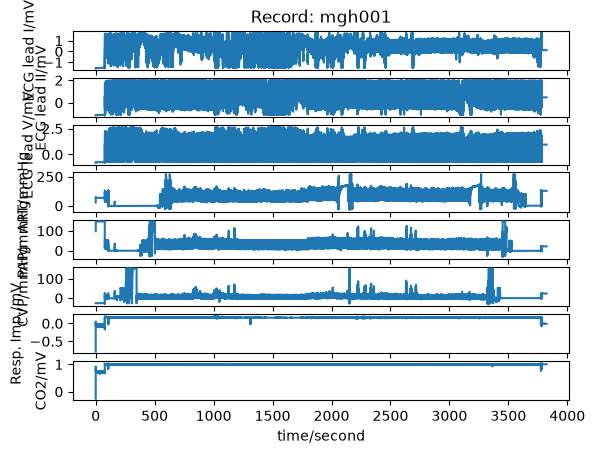

In [21]:
record = wfdb.rdrecord('mgh001', pn_dir='mghdb')

wfdb.plot_wfdb(record=record)

Found PA channel: PAP


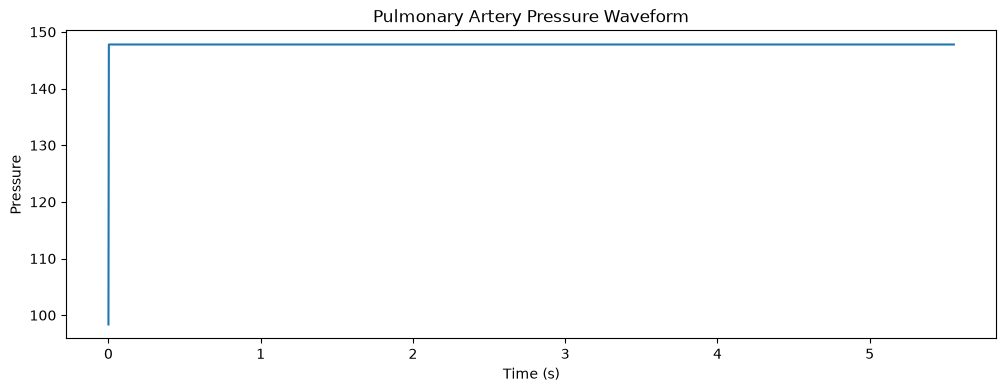

In [22]:
import numpy as np

# Find PA channel index
for i, name in enumerate(record.sig_name):
    if "PA" in name.upper():
        pa_idx = i
        print("Found PA channel:", name)

# Extract PA waveform
pa_signal = record.p_signal[:, pa_idx]

# Plot first few seconds (faster + clearer)
fs = record.fs
time = np.arange(len(pa_signal)) / fs

plt.figure(figsize=(12,4))
plt.plot(time[:2000], pa_signal[:2000])
plt.title("Pulmonary Artery Pressure Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Pressure")
plt.show()

In [23]:
import wfdb

# Load header only (fast)
record = wfdb.rdrecord('mgh001', pn_dir='mghdb')

print("Available channels:")
for i, name in enumerate(record.sig_name):
    print(i, name)

Available channels:
0 ECG lead I
1 ECG lead II
2 ECG lead V
3 ART
4 PAP
5 CVP
6 Resp. Imp.
7 CO2


['ECG lead I', 'ECG lead II', 'ECG lead V', 'ART', 'PAP', 'CVP', 'Resp. Imp.', 'CO2']


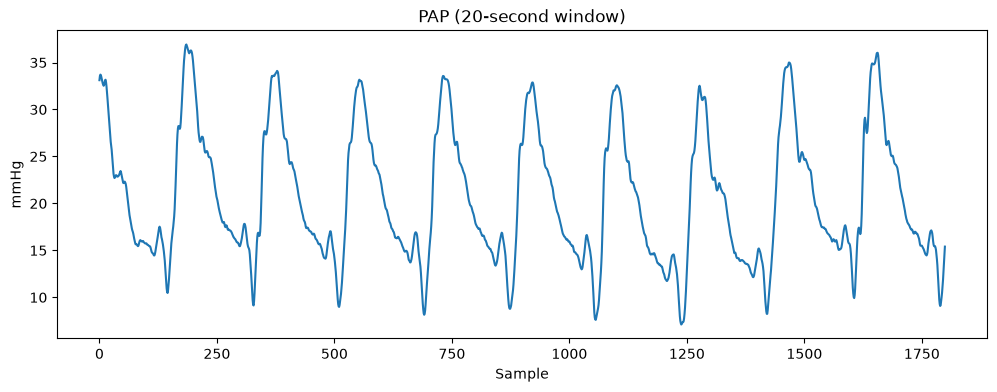

In [ ]:
# record = wfdb.rdrecord('mgh002', pn_dir='mghdb')
 
# wfdb.plot_wfdb(record=record)
 
# import wfdb
 
records = [
    "mgh001", "mgh006", "mgh007", "mgh008", "mgh010", "mgh011",
    "mgh013", "mgh014", "mgh015", "mgh016", "mgh017", "mgh020",
    "mgh021", "mgh022", "mgh023", "mgh024", "mgh025", "mgh026",
    "mgh027", "mgh028", "mgh029", "mgh031", "mgh032", "mgh033",
    "mgh034", "mgh035", "mgh036", "mgh037", "mgh038", "mgh039",
    "mgh042", "mgh043", "mgh044", "mgh045", "mgh047", "mgh049",
    "mgh050", "mgh051", "mgh052", "mgh053", "mgh055", "mgh056",
    "mgh057", "mgh058", "mgh061", "mgh062", "mgh063", "mgh064",
    "mgh065", "mgh066", "mgh067", "mgh068", "mgh069", "mgh070",
    "mgh071", "mgh072", "mgh073", "mgh074", "mgh075", "mgh082",
    "mgh084", "mgh086", "mgh088", "mgh093", "mgh096", "mgh097",
    "mgh099", "mgh103", "mgh107", "mgh109", "mgh111", "mgh112",
    "mgh113", "mgh114", "mgh116", "mgh120", "mgh121", "mgh122",
    "mgh123", "mgh124", "mgh126", "mgh128", "mgh130", "mgh136",
    "mgh137", "mgh138", "mgh139", "mgh140", "mgh141", "mgh142",
    "mgh143", "mgh144", "mgh145", "mgh146", "mgh147", "mgh149",
    "mgh150", "mgh153", "mgh155", "mgh156", "mgh163", "mgh164",
    "mgh165", "mgh167", "mgh168", "mgh169", "mgh170", "mgh171",
    "mgh172", "mgh173", "mgh174", "mgh181", "mgh182", "mgh183",
    "mgh184", "mgh185", "mgh186", "mgh188", "mgh190", "mgh193",
    "mgh196", "mgh197", "mgh198", "mgh204", "mgh205", "mgh206",
    "mgh207", "mgh208", "mgh209", "mgh210", "mgh211", "mgh212",
    "mgh213", "mgh214", "mgh215", "mgh216", "mgh217", "mgh218",
    "mgh219", "mgh220", "mgh221", "mgh223", "mgh224", "mgh225",
    "mgh228", "mgh230", "mgh235", "mgh236", "mgh237"
]
 
record = wfdb.rdrecord('mgh002', pn_dir='mghdb')
 
print(record.sig_name)
 
fs = record.fs  # sampling frequency
 
start_sec = 100
duration_sec = 5
 
start = int(start_sec * fs)
end = int((start_sec + duration_sec) * fs)
 
pap = record.p_signal[:, 4]
 
plt.figure(figsize=(12,4))
plt.plot(pap[start:end])
plt.title('PAP (20-second window)')
plt.ylabel('mmHg')
plt.xlabel('Sample')
plt.show()